In [1]:
import os
import sys
import re
import numpy as np
import pandas as pd
import plotly.express as px
import scipy.stats as stats
from dash import html, dcc, Input, Output, Dash
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sys.path.append(os.path.join(os.getcwd(), '..', '..'))
from baseVR.base_functionality import init_import_paths
init_import_paths() 

from CustomLogger import CustomLogger as Logger
from analytics_processing import analytics

from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args, fullfnames2snames
from dashsrc.plot_components.plots import plot_TrackFiringRate
from dashsrc.plot_components.plots import plot_unit_fr_stability

# from ..dashsrc.plot_components.plots import plot_TrackFiringRate
# from ..dashsrc.plot_components.plot_wrappers import wrapper_TrackFiringRate


In [2]:
Logger().init_logger(None, None, logging_level="DEBUG")
animal_ids = [6]
paradigm = [1100]
session_range = [1,33]
session_ids = None
normalize = True
smooth = False
excl_session_names = None  #['2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min', '2025-01-21_18-49_rYL006_P1100_LinearTrackStop_30min', '2024-12-11_17-42_rYL006_P1100_LinearTrackStop_30min']

session_dirs = sessionlist_fullfnames_from_args(paradigm, animal_ids, session_ids, excl_session_names=excl_session_names)[0]
session_names= fullfnames2snames(session_dirs)

2026-01-30 19:06:19,887|DEBUG|39763|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
2026-01-30 19:06:20,573|DEBUG|39763|sessions_from_nas_parsing|get_sessionlist_fullfnames
	For paradigms [1100], animals [6], found 34 sessions.
2026-01-30 19:06:20,575|DEBUG|39763|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: [1100], animal_ids: [6], session_ids: None, from_date: None, to_date: None
	Merging 34 sessions



In [3]:
# sess_ids_beh = behav.index.get_level_values("session_id").unique()
# sess_ids_ens = pd.Index(ens_proj["session_id"].unique())
# sess_ids = [s for s in sess_ids_beh if s in set(sess_ids_ens)]

# all_sessions = []

# for s_id in sess_ids:
#     beh_s = behav.xs(s_id, level="session_id").copy()
#     ens_s = ens_proj.loc[ens_proj["session_id"] == s_id].copy()

#     # recover interval index for this session only
#     ens_s.index = pd.IntervalIndex.from_arrays(
#         ens_s.pop("from_ephys_timestamp"),
#         ens_s.pop("to_ephys_timestamp"),
#     )

#     ens_s = ens_s.drop(columns=["session_id"])

#     def time_bin_avg(posbin_data: pd.DataFrame) -> pd.DataFrame:
#         # remove rows that cannot define intervals
#         # posbin_data = posbin_data.dropna(
#         #     subset=["posbin_from_ephys_timestamp", "posbin_to_ephys_timestamp"]
#         # )
#         if posbin_data.empty:
#             return pd.DataFrame()

#         # convert to real NumPy ints (avoids nullable Int64 masked arrays)
#         from_posbin_t = posbin_data["posbin_from_ephys_timestamp"].to_numpy(dtype="int64")
#         to_posbin_t   = posbin_data["posbin_to_ephys_timestamp"].to_numpy(dtype="int64")

#         interval = pd.IntervalIndex.from_arrays(
#             from_posbin_t - 40_000,
#             to_posbin_t + 40_000,
#             closed="both",
#         )

#         mid = ens_s.index.mid

#         print("mid range:", mid.min(), mid.max())
#         print("interval range:", interval.left.min(), interval.right.max())

#         # assign each 40ms ensemble bin midpoint to a trial in this position bin
#         assigned_bin = pd.cut(
#             ens_s.index.mid,
#             bins=interval,
#             labels=posbin_data.trial_id[:-1],
#         )
#         trials_exist_mask = (assigned_bin.value_counts() != 0).values

#         # if nothing overlaps, return empty
#         if assigned_bin.notna().sum() == 0:
#             return pd.DataFrame()

#         # keep only overlapping bins
#         trial_proj = ens_s.loc[assigned_bin.notna()].copy().astype(np.float32)
#         trial_proj["posbin_t_edges"] = assigned_bin[assigned_bin.notna()]

#         posbin_trial_wise = trial_proj.groupby("posbin_t_edges", observed=True).mean()

#         # align metadata to the set of trials that actually exist
#         # vc = assigned_bin.value_counts()
#         # trials_exist = vc.index.to_numpy()
#         # trials_exist_mask = posbin_data["trial_id"].isin(trials_exist).to_numpy()

#         posbin_trial_wise["cue"] = posbin_data.loc[trials_exist_mask, "cue"].to_numpy()
#         posbin_trial_wise["trial_outcome"] = posbin_data.loc[trials_exist_mask, "trial_outcome"].to_numpy()
#         posbin_trial_wise["choice_R1"] = posbin_data.loc[trials_exist_mask, "choice_R1"].to_numpy()
#         posbin_trial_wise["choice_R2"] = posbin_data.loc[trials_exist_mask, "choice_R2"].to_numpy()
#         posbin_trial_wise["bin_length"] = interval.length[trials_exist_mask] / 1e6

#         posbin_trial_wise.index = posbin_data.loc[trials_exist_mask, "trial_id"].to_numpy()
#         return posbin_trial_wise

#     # group within session only
#     sess_out = beh_s.groupby("from_position_bin").apply(time_bin_avg)
#     if isinstance(sess_out, pd.DataFrame) and len(sess_out) > 0:
#         sess_out.index = sess_out.index.rename(["from_position_bin", "trial_id"])
#         sess_out = sess_out.reset_index(drop=False)
#         sess_out["session_id"] = s_id
#         all_sessions.append(sess_out)

# all_sessions


In [4]:
# firing rates and behavior data
fr = analytics.get_analytics('FiringRate40msHz', session_names=session_names)
fr_track = analytics.get_analytics('FiringRateTrackwiseHz', session_names=session_names)
fr_z_scored  = analytics.get_analytics('FiringRate40msZ', session_names=session_names)
fr_z_all_sess = fr.apply(lambda unit_fr: ((unit_fr - unit_fr.mean()) / unit_fr.std()))
behav = analytics.get_analytics('BehaviorTrackwise', session_names=session_names)
behav.index = behav.index.droplevel(('animal_id', 'paradigm_id', 'entry_id'))

2026-01-30 19:06:20,600|DEBUG|39763|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-01-30 19:06:20,817|DEBUG|39763|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2026-01-30 19:06:20,823|DEBUG|39763|analytics|get_analytics
	Processing FiringRate40msHz, (6, 1100, 0) 2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min.hdf5
/Volumes/large/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min
2026-01-30 19:06:20,836|INFO|39763|analytics|get_analytics
	Analytic `FiringRate40msHz` does not exist for (6, 1100, 0), compute first, or check for typo
2026-01-30 19:06:20,838|DEBUG|39763|analytics|get_analytics
	Processing FiringRate40msHz, (6, 1100, 1) 2024-11-14_16-40_rYL006_P1100_LinearTrackStop_21min.hdf5
/Volumes/large/BMI/VirtualReality/SpatialSequenceL

In [5]:
# ensamble related data
ensambles = analytics.get_analytics('ConcatenatedEnsambles40ms', session_names=session_names)
ens_data = analytics.get_analytics('TrackwiseEnsembleProj', session_names=session_names)
ensamble_proj = analytics.get_analytics('ConcatenatedEnsambleProj40ms', session_names=session_names)#.drop("to_ephys_timestamp", axis=1)
ensamble_proj.set_index(['session_id'], inplace = True)
ens_data = ens_data.set_index(['session_id', 'trial_id']).sort_index()

2026-01-30 19:07:38,212|DEBUG|39763|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-01-30 19:07:38,515|DEBUG|39763|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2026-01-30 19:07:38,516|DEBUG|39763|analytics|get_analytics
	Processing ConcatenatedEnsambles40ms, for n=34 sessions
2026-01-30 19:07:38,558|DEBUG|39763|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-01-30 19:07:38,560|DEBUG|39763|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2026-01-30 19:07:38,561|DEBUG|39763|analytics|get_analytics
	Processing TrackwiseEnsembleProj, for n=34 sessions


/Volumes/large/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/ConcatenatedEnsambles40ms.parquet
/Volumes/large/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/TrackwiseEnsembleProj.parquet


2026-01-30 19:07:47,454|DEBUG|39763|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-01-30 19:07:47,464|DEBUG|39763|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2026-01-30 19:07:47,465|DEBUG|39763|analytics|get_analytics
	Processing ConcatenatedEnsambleProj40ms, for n=34 sessions


/Volumes/large/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/ConcatenatedEnsambleProj40ms.parquet


In [6]:
# df = ens_data.reset_index() 
sessions_keep = [8, 9, 11, 12, 13, 14, 15, 16] #C1 strategy
# sessions_keep = [15, 16, 17, 18, 19, 20, 21, 22, 23] #C2 strategy
#sessions_keep = [23] 



# keep only expert trials (C1 cue -> choice_R1 = True, choice_R2 = False; C2 cue -> choice_R1 = False, choice_R2 = True)
ens_filt = ens_data.loc[ens_data.index.get_level_values("session_id").isin(sessions_keep)]

ens_filt = ens_data.copy()

# expert1 = ens_filt[ # Keep only expert trials
#         (ens_filt["choice_R1"] == 1) &
#         (ens_filt["choice_R2"] == 0) &
#         (ens_filt["cue"] == 1)
#     ]

# expert2 = ens_filt[ # Keep only expert trials
#         (ens_filt["choice_R1"] == 0) &
#         (ens_filt["choice_R2"] == 1) &
#         (ens_filt["cue"] == 2)
#     ]

expert1 = ens_filt[ # Keep only non expert trials
        (ens_filt["choice_R1"] == 0) &
        (ens_filt["cue"] == 1)
    ]

expert2 = ens_filt[ # Keep only non expert trials
        (ens_filt["choice_R2"] == 0) &
        (ens_filt["choice_R1"] == 1) &
        (ens_filt["cue"] == 2)
    ]



ens_filt = pd.concat([expert1, expert2])


trial_avg = (
    ens_filt # .reset_index()
    .groupby(["from_position_bin", "cue"], as_index=False)["Assembly012"]
    .mean()
    .rename(columns={"Assembly012": "Assembly012_mean"})
)

# 2) Keep only cue 1 and 2
trial_avg = trial_avg[trial_avg["cue"].isin([1, 2])]

# 3) Ensure one bar per discrete trial_id (no numeric binning)
trial_avg["from_position_bin"] = trial_avg["from_position_bin"].astype(str)

cue1 = trial_avg[trial_avg["cue"] == 1]
cue2 = trial_avg[trial_avg["cue"] == 2]

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=cue1["from_position_bin"],
        y=cue1["Assembly012_mean"],
        name="cue 1",
        marker_color = 'orange',
        opacity=0.7,
    )
)


fig.add_trace(
    go.Bar(
        x=cue2["from_position_bin"],
        y=cue2["Assembly012_mean"],
        name="cue 2",
        marker_color = 'purple',
        opacity=0.4,
    )
)

fig.update_layout(
    # title = f"Average Ensemble Activity trackwise - Sessions {min(sessions_keep)} to {max(sessions_keep)}",
    title = f"Average Ensemble Activity trackwise - All Sessions (Expert only)",
    barmode="overlay",  # use "group" for side-by-side bars
    xaxis_title="from_position_bin",
    yaxis_title="Avg(Assembly012) per position bin",
    bargap=0.05,
)

fig.update_xaxes(type="linear")
fig.update_yaxes(range=[min(trial_avg["Assembly012_mean"]), 1])

fig.add_vrect(x0=-80, x1=25,  fillcolor="orange", opacity=0.1, layer="below", line_width=0)
fig.add_vrect(x0=50,  x1=110, fillcolor="grey",   opacity=0.1, layer="below", line_width=0)
fig.add_vrect(x0=170, x1=230, fillcolor="grey",   opacity=0.1, layer="below", line_width=0)


fig.show()



In [7]:
# import matplotlib.pyplot as plt
# plt.close('all')
# for i in range(ens_data.shape[1]):
#     plt.figure()
#     plt.hist(np.clip(ens_data.iloc[:, i], -4, 7), bins=100, color='steelblue', alpha=0.7, range=(-4, 7))
#     plt.title(f'Ensamble {i} projection - overall activation strength')
#     plt.show()

In [8]:
#ordering neurons by weight in ens
neurons_ordered = abs(ensambles['Assembly012']).sort_values(ascending=True).index
neurons_ordered

Index([ 4, 29, 43, 76, 10, 58, 25, 27, 13, 37, 59, 46, 47, 75, 57, 19, 20, 34,
       67,  5, 42, 73, 66, 60, 61, 70, 49, 28, 18, 30, 17, 63, 41,  3, 54, 52,
       33, 39, 16,  9, 26, 69,  0, 44, 40,  6, 38, 12, 45, 71, 55, 32, 51, 31,
        1, 64, 53, 21, 56, 74, 72,  2, 35, 65,  7, 62,  8, 36, 68, 23, 14, 24,
       22, 48, 15, 11, 50],
      dtype='int64')

In [9]:
meta_data = {}
meta_data['SpikeClusterMetadata'] = analytics.get_analytics('SpikeClusterMetadata', mode='set',
                                                      #  columns = cols,
                                                       paradigm_ids=paradigm,
                                                       animal_ids=animal_ids,
                                                       excl_session_names=excl_session_names,
                                                       session_ids=session_ids)

# # HPC
# meta_data['SpikeClusterMetadata'] = meta_data['SpikeClusterMetadata'][meta_data['SpikeClusterMetadata'].cluster_id<=20]
# # mPFC
# meta_data['SpikeClusterMetadata'] = meta_data['SpikeClusterMetadata'][meta_data['SpikeClusterMetadata'].cluster_id<20]
# meta_data['SpikeClusterMetadata']

2026-01-30 19:08:18,365|DEBUG|39763|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
2026-01-30 19:08:19,496|DEBUG|39763|sessions_from_nas_parsing|get_sessionlist_fullfnames
	For paradigms [1100], animals [6], found 34 sessions.
2026-01-30 19:08:19,766|DEBUG|39763|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: [1100], animal_ids: [6], session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2026-01-30 19:08:19,770|DEBUG|39763|analytics|get_analytics
	Processing SpikeClusterMetadata, (1100, 6, 0) 2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min.hdf5
/Volumes/large/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min
2026-01-30 19:08:19,790|INFO|39763|analytics|get_analytics
	Analytic `SpikeClusterMetadata` does not exist for (1100, 6, 0), compute first, or check for typo
2026-01-30 19:08:19,792|DEBUG|39763|analytics|get_analytics
	P

In [10]:
i = "Assembly012"
fig_heat = plot_unit_fr_stability.render_plot_heatmap(meta_data["SpikeClusterMetadata"])
heatmap = fig_heat.data[0]

current_labels = np.array(fig_heat.layout.yaxis.ticktext, dtype=str)

desired_order = np.array( neurons_ordered[::]+1, dtype=str)
desired_order = [lab for lab in desired_order if lab in current_labels]

label_to_row = {lab: j for j, lab in enumerate(current_labels)}
row_indices = [label_to_row[lab] for lab in desired_order]

z = np.array(heatmap.z)
z_reordered = z[row_indices, :]
xlabels = np.array(fig_heat.layout.xaxis.ticktext, dtype=str)

# subplot creation
fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.3, 0.7],
    subplot_titles=("Ensemble 12", "Average Firing Rate per Neuron/Session"),
)

# Left plot
ens_idx_str = (ensambles.index+1).astype(str)
weights = pd.Series(ensambles[i].values, index=ens_idx_str)

# HPC mPC split
labels_hp   = ens_idx_str[:20]
labels_mpfc = ens_idx_str[20:]

# reorder those labels according to desired_order (same as heatmap y)
labels_hp_ordered   = [lab for lab in desired_order if lab in labels_hp]
labels_mpfc_ordered = [lab for lab in desired_order if lab in labels_mpfc]

w_hp   = weights.loc[labels_hp_ordered].to_numpy()
w_mpfc = weights.loc[labels_mpfc_ordered].to_numpy()

def make_stem_lines(x_vals, y_labels, color):
    """Horizontal 'stems' at categorical y positions."""
    xs, ys = [], []
    for x, ylab in zip(x_vals, y_labels):
        xs.extend([0, x, None])
        ys.extend([ylab, ylab, None])
    return go.Scatter(
        x=xs,
        y=ys,
        mode="lines",
        line=dict(color=color),
        showlegend=False,
        hoverinfo="skip",
    )

hp_stems = make_stem_lines(w_hp,   labels_hp_ordered,   color="blue")
mpfc_stems = make_stem_lines(w_mpfc, labels_mpfc_ordered, color="magenta")

hp_markers = go.Scatter(
    x=w_hp,
    y=labels_hp_ordered,
    mode="markers",
    name=f"{i}, HP",
    marker=dict(color="blue", symbol="circle"),
)

mpfc_markers = go.Scatter(
    x=w_mpfc,
    y=labels_mpfc_ordered,
    mode="markers",
    name=f"{i}, mPFC",
    marker=dict(color="magenta", symbol="circle"),
)

thr = 0.2
mask = np.abs(weights.values) > thr
x_high = weights.values[mask]
y_high = ens_idx_str[mask]  

highlight = go.Scatter(
    x=x_high,
    y=y_high,
    mode="markers",
    name="Otsu thresh.",
    marker=dict(
        size=10,
        color="rgba(0,0,0,0)",
        line=dict(color="black", width=2),
        symbol="circle",
    ),
)

fig.add_trace(hp_stems,     row=1, col=1)
fig.add_trace(mpfc_stems,   row=1, col=1)
fig.add_trace(hp_markers,   row=1, col=1)
fig.add_trace(mpfc_markers, row=1, col=1)
fig.add_trace(highlight,    row=1, col=1)

fig.update_xaxes(
    title_text="Weight",
    range=[-0.45, 0.45],
    row=1,
    col=1,
)

fig.update_yaxes(
    title_text="Neurons",
    categoryorder="array",
    categoryarray=desired_order,
    dtick=1,
    row=1,
    col=1,
)

fig.add_vline(
    x=0,
    line_width=1,
    line_color="black",
    row=1,
    col=1,
)

# Heatmap
heatmap_trace = go.Heatmap(
    z=z_reordered,
    x=xlabels,
    y=desired_order,
    colorscale=heatmap.colorscale,
    zmin=heatmap.zmin,
    zmax=heatmap.zmax,
    colorbar=dict(
        title=heatmap.colorbar.title.text,
        tickvals=heatmap.colorbar.tickvals,
        ticktext=heatmap.colorbar.ticktext,
        tickmode=heatmap.colorbar.tickmode,
        len=heatmap.colorbar.len,
        thickness=heatmap.colorbar.thickness,
        tickfont=dict(size=heatmap.colorbar.tickfont.size),
    ),
)

fig.add_trace(heatmap_trace, row=1, col=2)

fig.update_xaxes(
    title_text=fig_heat.layout.xaxis.title.text,
    row=1,
    col=2,
)

fig.update_yaxes(
    title_text=fig_heat.layout.yaxis.title.text,
    categoryorder="array",
    dtick=1,
    categoryarray=desired_order,
    row=1,
    col=2,
)

fig.update_layout(
    template="plotly_white",
    width=1000,
    height=800,
    legend=dict(font=dict(size=6)),
)

fig.show()


In [11]:
session_used = 16 
neuron_data_s15 = fr.xs(session_used, level=2)

# Filter Unit columns only
unit_cols = [col for col in neuron_data_s15.columns if isinstance(col, str) and col.startswith('Unit')]
neuron_data_s15 = neuron_data_s15[unit_cols]

# Compute correlation matrix (neuron vs neuron)
corr_matrix = neuron_data_s15.corr()

# Create ordering based on reversed neurons_ordered
# neurons_ordered contains indices 0-76, map to Unit column names
reversed_order = neurons_ordered[::-1]
unit_order = [f'Unit{i+1:04d}' for i in reversed_order if f'Unit{i+1:04d}' in corr_matrix.columns]

# Reorder the correlation matrix
corr_matrix_ordered = corr_matrix.loc[unit_order, unit_order]

# Create heatmap
fig = px.imshow(
    corr_matrix_ordered,
    aspect='auto',
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    labels=dict(x="Neurons", y="Neurons", color="Pearson r"),
    title=f"Neuron-Neuron Pearson Correlation Matrix (Session {session_used}, Assembly012)"
)

fig.update_xaxes(tickangle=90, tickfont=dict(size=6))
fig.update_yaxes(tickfont=dict(size=6))
fig.update_layout(width=800, height=800)

fig.show()

In [12]:
# selecting only the rows of fr_track where column from_position_bin  is between 148 and 151
fr_track_selected = fr_track[(fr_track['from_position_bin'] >= (-95)) & (fr_track['from_position_bin'] <= 10)] # cue zone

# further filter to rows where cue == 1
fr_track_selected = fr_track_selected[fr_track_selected['cue'] == 1]
fr_track_selected = fr_track_selected[fr_track_selected['choice_R2'] == False]

In [13]:
# set top x neurons and select sessions
top_x_neurons = neurons_ordered[-20:]
session_ids_all = range(12, 28) #fr_track.index.get_level_values('session_id').unique().sort_values()

# drop session 10 and 17
session_ids_all = [s for s in session_ids_all if s not in [10,24,25,29,31]]

n_sessions = len(session_ids_all)

n_cols = 4 # int(np.ceil(np.sqrt(n_sessions)))
n_rows = 3 # int(np.ceil(n_sessions / n_cols))

reversed_order_topx = top_x_neurons[::-1]

# Create subplots
fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=[f'S{s}' for s in session_ids_all],
    horizontal_spacing=0.02,
    vertical_spacing=0.03
)

# Compute correlation matrix for each session (only top 10 neurons)
for idx, session_id in enumerate(session_ids_all):
    row = idx // n_cols + 1
    col = idx % n_cols + 1
    
    # Extract session data
    try:
        neuron_data_session = fr_track_selected.xs(session_id, level=2)
        
        # Filter to Unit columns only
        unit_cols = [c for c in neuron_data_session.columns if isinstance(c, str) and c.startswith('Unit')]
        neuron_data_session = neuron_data_session[unit_cols]
        
        # Map top 10 neurons to Unit column names
        topx_unit_cols = [f'Unit{i+1:04d}' for i in top_x_neurons if f'Unit{i+1:04d}' in neuron_data_session.columns]
        
        # Filter to only top 10 neurons
        neuron_data_top10 = neuron_data_session[topx_unit_cols]
        
        # Compute correlation matrix
        corr_matrix = neuron_data_top10.corr()
        
        # Create ordering based on reversed top 10 neurons
        unit_order = [f'Unit{i+1:04d}' for i in reversed_order_topx if f'Unit{i+1:04d}' in corr_matrix.columns]
        
        # Reorder the correlation matrix
        corr_matrix_ordered = corr_matrix.loc[unit_order, unit_order]
        
        # Add heatmap to subplot
        fig.add_trace(
            go.Heatmap(
                z=corr_matrix_ordered.values,
                x=unit_order,
                y=unit_order,
                colorscale='RdBu_r',
                zmin=-1,
                zmax=1,
                showscale=(idx == 0),
                colorbar=dict(
                    title="Pearson r",
                    x=1.02
                ) if idx == 0 else None,
                hovertemplate='X: %{x}<br>Y: %{y}<br>r: %{z:.3f}<extra></extra>'
            ),
            row=row,
            col=col
        )
        
        # Update axes - show tick labels for top 10
        fig.update_xaxes(showticklabels=True, tickangle=90, tickfont=dict(size=5), row=row, col=col)
        fig.update_yaxes(showticklabels=True, tickfont=dict(size=5), row=row, col=col)
        
    except Exception as e:
        print(f"Error processing session {session_id}: {e}")
        continue

# Update layout
fig.update_layout(
    title_text=f"Top 20 Most Weighted Neurons: Pearson Correlation Matrices Across Sessions 9-16<br>(Assembly012 ordered by weights)",
    title_font_size=16,
    width=300 * n_cols,
    height=300 * n_rows,
    showlegend=False
)

fig.show()

print(f"Created {n_sessions} correlation heatmaps (10x10) in {n_rows}x{n_cols} grid")
print(f"Top 10 most weighted neurons: {top_x_neurons.values}")

Error processing session 26: The (row, col) pair sent is out of range. Use Figure.print_grid to view the subplot grid. 
Error processing session 27: The (row, col) pair sent is out of range. Use Figure.print_grid to view the subplot grid. 


Created 14 correlation heatmaps (10x10) in 3x4 grid
Top 10 most weighted neurons: [21 56 74 72  2 35 65  7 62  8 36 68 23 14 24 22 48 15 11 50]


In [14]:
top_ns = [5, 10, 20, 77]
session_ids_all = list(range(9, 33))
session_ids_all = [s for s in session_ids_all if s not in [10, 24, 25, 29, 31]]
fr_used = fr_z_all_sess

def mean_offdiag_corr(corr_df: pd.DataFrame) -> float:
    k = corr_df.shape[0]
    if k < 2:
        return np.nan
    iu = np.triu_indices(k, k=1)
    vals = corr_df.to_numpy()[iu]
    return float(np.nanmean(vals))

# second y-axis for ensemble mean
fig = make_subplots(specs=[[{"secondary_y": True}]])

for top_n in top_ns:
    top_n_neurons = neurons_ordered[-top_n:]
    rows = []

    for session_id in session_ids_all:
        try:
            neuron_data_session = fr_used.xs(session_id, level=2) 

            unit_cols = [
                c for c in neuron_data_session.columns
                if isinstance(c, str) and c.startswith("Unit")
            ]
            neuron_data_session = neuron_data_session[unit_cols]

            top_unit_cols = [
                f"Unit{i+1:04d}" for i in top_n_neurons
                if f"Unit{i+1:04d}" in neuron_data_session.columns
            ]

            neuron_data_top = neuron_data_session[top_unit_cols]
            print(neuron_data_top.keys())
            corr = neuron_data_top.corr(method="pearson")
            avg_corr = mean_offdiag_corr(corr)

            rows.append((session_id, avg_corr))
        except Exception:
            rows.append((session_id, np.nan))

    df_avg = pd.DataFrame(rows, columns=["session_id", "avg_pairwise_corr"])

    fig.add_trace(
        go.Scatter(
            x=df_avg["session_id"],
            y=df_avg["avg_pairwise_corr"],
            mode="lines+markers",
            name=f"top {top_n}",
        ),
        secondary_y=False,
    )

# ensemble mean per session (one trace on the right y-axis)
ens_mean = (
    ensamble_proj["Assembly012"]
    .groupby(level=0)
    .mean()
    .reindex(session_ids_all)
)

fig.add_trace(
    go.Scatter(
        x=ens_mean.index,
        y=ens_mean.values,
        mode="lines+markers",
        name="Ensemble mean (Assembly012)",
    ),
    secondary_y=True,
)

fig.update_layout(
    title="Average pairwise Pearson correlation across sessions",
    width=900,
    height=450,
)

fig.update_xaxes(title_text="Session")

fig.update_yaxes(
    title_text="Average pairwise correlation (Pearson r)",
    range=[-1, 1],
    secondary_y=False,
)

fig.update_yaxes(
    title_text="Ensemble activation (mean)",
    secondary_y=True,
)

fig.show()


Index(['Unit0023', 'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'], dtype='object')
Index(['Unit0023', 'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'], dtype='object')
Index(['Unit0023', 'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'], dtype='object')
Index(['Unit0023', 'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'], dtype='object')
Index(['Unit0023', 'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'], dtype='object')
Index(['Unit0023', 'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'], dtype='object')
Index(['Unit0023', 'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'], dtype='object')
Index(['Unit0023', 'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'], dtype='object')
Index(['Unit0023', 'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'], dtype='object')
Index(['Unit0023', 'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'], dtype='object')
Index(['Unit0023', 'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'], dtype='object')
Index(['Unit0023', 'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'], dtype='o

Index(['Unit0023', 'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'], dtype='object')
Index(['Unit0023', 'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'], dtype='object')
Index(['Unit0037', 'Unit0069', 'Unit0024', 'Unit0015', 'Unit0025', 'Unit0023',
       'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'],
      dtype='object')
Index(['Unit0037', 'Unit0069', 'Unit0024', 'Unit0015', 'Unit0025', 'Unit0023',
       'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'],
      dtype='object')
Index(['Unit0037', 'Unit0069', 'Unit0024', 'Unit0015', 'Unit0025', 'Unit0023',
       'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'],
      dtype='object')
Index(['Unit0037', 'Unit0069', 'Unit0024', 'Unit0015', 'Unit0025', 'Unit0023',
       'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'],
      dtype='object')
Index(['Unit0037', 'Unit0069', 'Unit0024', 'Unit0015', 'Unit0025', 'Unit0023',
       'Unit0049', 'Unit0016', 'Unit0012', 'Unit0051'],
      dtype='object')
Index(['Unit0037', 'Unit0069', 'Unit0024', 'Uni

In [15]:
top_ns = [10, 20, 77]
fr_used = fr_z_all_sess.copy()

# 2x2 layout: correlations on first row, firing rates on second row
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Pearson corr (unweighted)", "Pearson corr (weighted)",
        "Mean firing rate (unweighted)", "Mean firing rate (weighted)"
    ),
    shared_yaxes=False,
)

weights = ensambles["Assembly012"]
try:
    weights.index = [f"Unit{int(i)+1:04d}" for i in weights.index]  # align to FR column naming
except Exception as e:
    print(f"Error setting weights index: {e}")



# pearson correlations for single neurons weighted and unweightes
for top_n in top_ns:
    top_n_neurons = neurons_ordered[-top_n:]
    rows_unw, rows_w = [], []

    for session_id in session_ids_all:
        neuron_data_session = fr_used.xs(session_id, level=2)

        unit_cols = [
            c for c in neuron_data_session.columns
            if isinstance(c, str) and c.startswith("Unit")
        ]
        neuron_data_session = neuron_data_session[unit_cols]

        top_unit_cols = [
            f"Unit{i+1:04d}" for i in top_n_neurons
            if f"Unit{i+1:04d}" in neuron_data_session.columns
        ]

        neuron_data_top = neuron_data_session[top_unit_cols]

        corr_unw = neuron_data_top.corr(method="pearson")
        rows_unw.append((session_id, mean_offdiag_corr(corr_unw)))

        w = weights.loc[top_unit_cols]
        neuron_data_top_w = neuron_data_top.mul(w, axis=1)
        corr_w = neuron_data_top_w.corr(method="pearson")
        rows_w.append((session_id, mean_offdiag_corr(corr_w)))

    df_unw = pd.DataFrame(rows_unw, columns=["session_id", "avg_corr"])
    df_w = pd.DataFrame(rows_w, columns=["session_id", "avg_corr"])

    fig.add_trace(
        go.Scatter(
            x=df_unw["session_id"],
            y=df_unw["avg_corr"],
            mode="lines+markers",
            name=f"top {top_n}",
            legendgroup=f"top{top_n}",
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Scatter(
            x=df_w["session_id"],
            y=df_w["avg_corr"],
            mode="lines+markers",
            name=f"top {top_n}",
            legendgroup=f"top{top_n}",
            showlegend=False,  # avoid duplicated legend entries
        ),
        row=1,
        col=2,
    )


# mean fr
fr_units = fr_used.loc[:, fr_used.columns.str.startswith("Unit")]
# fr_units = fr.loc[:, fr.columns.str.startswith("Unit")]
fr_units = fr_units[fr_units.index.get_level_values(2) != 10]

w_all = ensambles["Assembly012"].copy()
w_all = w_all.reindex(fr_units.columns)
fr_units_weighted = fr_units.mul(w_all, axis=1)

session_means_unweighted = (
    fr_units
    .groupby(level=2)
    .mean()
    .mean(axis=1)
)

session_means_weighted = (
    fr_units_weighted
    .groupby(level=2)
    .mean()
    .mean(axis=1)
)

fig.add_scatter(
    x=session_means_unweighted.index,
    y=session_means_unweighted.values,
    mode="lines+markers",
    name="Mean FR unweighted",
    row=2,
    col=1,
)

fig.add_scatter(
    x=session_means_weighted.index,
    y=session_means_weighted.values,
    mode="lines+markers",
    name="Mean FR weighted",
    row=2,
    col=2,
)


fig.update_layout(
    title="Session-wise Pearson correlations (top row) and mean firing rates (bottom row)",
    width=1200,
    height=800,
)

fig.update_xaxes(title_text="Session", row=1, col=1)
fig.update_xaxes(title_text="Session", row=1, col=2)
fig.update_xaxes(title_text="Session", row=2, col=1)
fig.update_xaxes(title_text="Session", row=2, col=2)

fig.update_yaxes(title_text="Avg pairwise Pearson r", row=1, col=1)
fig.update_yaxes(title_text="Avg pairwise Pearson r", row=1, col=2)
fig.update_yaxes(title_text="Mean firing rate (z-scored)", row=2, col=1)
fig.update_yaxes(title_text="Mean firing rate (z-scored)", row=2, col=2)

fig.update_yaxes(range=[-1, 1], row=1, col=1)
fig.update_yaxes(range=[-1, 1], row=1, col=2)

fig.show()


In [16]:
sessions = [16, ]
assembly_name = "Assembly012"
target = "rms_a"                 # "var_a" 
min_T = 200                      # minimum time bins after filtering
min_finite_frac_per_unit = 0.99  # keep units that are finite in >=99% of rows for that session
min_units = 10
renorm_weights = True

# inputs
# selecting only sessions 14 - 18


Z_df = fr_z_all_sess.copy()#.loc[fr.index.get_level_values("session_id").isin(sessions)]
unit_cols = [c for c in Z_df.columns if isinstance(c, str) and c.startswith("Unit")]
if not unit_cols:
    raise ValueError("No 'UnitXXXX' columns found in fr_z_scored.")

w_raw = ensambles[assembly_name].copy()
if not all(isinstance(i, str) and i.startswith("Unit") for i in w_raw.index):
    try:
        w_raw.index = [f"Unit{int(i)+1:04d}" for i in w_raw.index]
    except Exception as e:
        raise ValueError("Could not map weight index to UnitXXXX.") from e

# Use only units present in data
units_all = [u for u in w_raw.index if u in unit_cols]
if len(units_all) < 2:
    raise ValueError("Too few overlapping units between weights and fr_z_scored.")

Z_units = Z_df[units_all]

def iter_sessions(Z: pd.DataFrame):
    if isinstance(Z.index, pd.MultiIndex) and "session_id" in Z.index.names:
        for s in sorted(Z.index.get_level_values("session_id").unique()):
            yield s, Z.xs(s, level="session_id")
        return
    if Z.index.name == "session_id":
        for s in sorted(Z.index.unique()):
            yield s, Z.loc[s]
        return
    if "session_id" in Z.columns:
        for s, g in Z.groupby("session_id", sort=True):
            yield s, g.drop(columns=["session_id"])
        return
    raise ValueError("Cannot find session_id in fr_z_scored (neither index level nor column).")


# Per-session computation with column-wise filtering

rows = []
Sigma_by_session = {}
units_by_session = {}
w_by_session = {}

for s, Z_s in iter_sessions(Z_units):
    X = np.asarray(Z_s.values, dtype=float)  # shape (T, N_all)
    T_raw, N_all = X.shape

    if T_raw == 0:
        rows.append({"session_id": s, "T_raw": 0, "T_used": 0, "N_used": 0,
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    # keep units that are finite in most rows (per-session)
    finite_mask = np.isfinite(X)  # (T, N_all)
    finite_frac = finite_mask.mean(axis=0)  # (N_all,)
    keep_cols = finite_frac >= min_finite_frac_per_unit

    if keep_cols.sum() < min_units:
        rows.append({"session_id": s, "T_raw": T_raw, "T_used": 0, "N_used": int(keep_cols.sum()),
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    kept_units = list(np.array(units_all)[keep_cols])

    # subset X and drop rows that still have any NaN/inf (rare after column filter)
    Xk = X[:, keep_cols]
    ok_rows = np.isfinite(Xk).all(axis=1)
    Xk = Xk[ok_rows, :]
    T_used, N_used = Xk.shape

    if T_used < min_T or N_used < min_units:
        rows.append({"session_id": s, "T_raw": T_raw, "T_used": T_used, "N_used": N_used,
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    # align weights to kept units
    w_s = w_raw.loc[kept_units].astype(float).values

    # Optional: renormalize weights so that comparisons across sessions are not dominated by changing N_used
    if renorm_weights:
        norm = np.linalg.norm(w_s)
        if norm > 0:
            w_s = w_s / norm

    # assembly activation and covariance decomposition
    a = Xk @ w_s
    mean_a = float(np.mean(a))

    Sigma = np.cov(Xk, rowvar=False, bias=False)
    var_a = float(w_s.T @ Sigma @ w_s)
    diag_var = float(np.sum((w_s ** 2) * np.diag(Sigma)))
    offdiag_var = float(var_a - diag_var)

    rows.append({"session_id": s, "T_raw": T_raw, "T_used": T_used, "N_used": N_used,
                 "mean_a": mean_a, "var_a": var_a, "diag_var": diag_var, "offdiag_var": offdiag_var})

    Sigma_by_session[s] = Sigma
    units_by_session[s] = kept_units
    w_by_session[s] = w_s

metrics = pd.DataFrame(rows).set_index("session_id").sort_index()
metrics["rms_a"] = np.sqrt(metrics["var_a"])
metrics["diag_frac"] = metrics["diag_var"] / metrics["var_a"]
metrics["offdiag_frac"] = metrics["offdiag_var"] / metrics["var_a"]

display(metrics)

# Find largest drop safely
valid = metrics[target].dropna()
if valid.shape[0] < 2:
    raise ValueError(
        f"Not enough valid sessions for target={target}. "
        f"Valid sessions={valid.shape[0]}. "
        f"Try lowering min_T, lowering min_finite_frac_per_unit, or check why many units are NaN."
    )

delta = valid.diff().dropna()
drop_session = delta.idxmin()
prev_session = valid.index[valid.index.get_loc(drop_session) - 1]

print(f"\nLargest drop in {target}: session {prev_session} -> {drop_session} (Δ={delta.loc[drop_session]:.6g})")
print(f"Session sizes: prev(T={metrics.loc[prev_session,'T_used']}, N={metrics.loc[prev_session,'N_used']}), "
      f"drop(T={metrics.loc[drop_session,'T_used']}, N={metrics.loc[drop_session,'N_used']})")


# Attribution for that drop (only on common kept units)
U_prev = units_by_session[prev_session]
U_drop = units_by_session[drop_session]
common_units = sorted(set(U_prev).intersection(U_drop))

if len(common_units) < min_units:
    raise ValueError(
        f"Too few common units between prev and drop sessions for attribution: {len(common_units)}. "
        f"This indicates strong session-to-session changes in which units are finite."
    )

# Recompute Sigma on common units only (consistent dimensionality)
def get_X_session_common(s, common_units):
    Z_s = next(g for sid, g in iter_sessions(Z_units) if sid == s)  # session df with all units_all
    X = Z_s[common_units].to_numpy(dtype=float)
    ok = np.isfinite(X).all(axis=1)
    return X[ok, :]

X_prev = get_X_session_common(prev_session, common_units)
X_drop = get_X_session_common(drop_session, common_units)

if X_prev.shape[0] < min_T or X_drop.shape[0] < min_T:
    raise ValueError("After restricting to common units, not enough finite rows remain for covariance.")

Sigma_prev = np.cov(X_prev, rowvar=False, bias=False)
Sigma_drop = np.cov(X_drop, rowvar=False, bias=False)
dSigma = Sigma_drop - Sigma_prev

# weights restricted to common units (and optionally renormalized)
w_common = w_raw.loc[common_units].astype(float).values
if renorm_weights:
    norm = np.linalg.norm(w_common)
    if norm > 0:
        w_common = w_common / norm

dVar_total = float(w_common.T @ dSigma @ w_common)
dVar_diag  = float(np.sum((w_common ** 2) * np.diag(dSigma)))
dVar_off   = float(dVar_total - dVar_diag)

print(f"\nAttribution on common units (N={len(common_units)}):")
print(f" delta Var(a) total:   {dVar_total:.6g}")
print(f"  diagonal part: {dVar_diag:.6g}")
print(f"  offdiag part:  {dVar_off:.6g}")

# unit and pair driver scores
unit_driver = pd.Series((w_common ** 2) * np.diag(dSigma), index=common_units).sort_values()

C = np.outer(w_common, w_common) * dSigma
np.fill_diagonal(C, 0.0)

pair_rows = []
N = len(common_units)
for i in range(N):
    for j in range(i + 1, N):
        pair_rows.append((common_units[i], common_units[j], C[i, j]))

pair_driver = pd.DataFrame(pair_rows, columns=["unit_i", "unit_j", "pair_score"]).sort_values("pair_score")

print("\nTop unit-level diagonal drivers (most negative):")
display(unit_driver.head(15).to_frame("d_i = w_i^2 * Sigma_ii"))

print("\nTop pair-level off diagonal drivers (most negative):")
display(pair_driver.head(20))


,T_raw,T_used,N_used,mean_a,var_a,diag_var,offdiag_var,rms_a,diag_frac,offdiag_frac
session_id,,,,,,,,,,
1,32200,32200,77,-0.587848,0.855076,0.721074,0.134002,0.924703,0.843287,0.156713
2,53592,53592,77,-0.931100,1.235253,1.002494,0.232759,1.111419,0.811570,0.188430
3,33834,33834,77,-0.580334,1.258148,0.873254,0.384894,1.121672,0.694079,0.305921
4,38805,38805,77,-0.648255,1.048759,0.758276,0.290483,1.024089,0.723022,0.276978
6,27459,27459,77,-0.420814,1.154376,0.808455,0.345921,1.074419,0.700339,0.299661
7,38213,38213,77,-0.779637,1.105578,0.783918,0.321660,1.051464,0.709057,0.290943
9,46119,46119,77,-1.037247,1.171773,0.870666,0.301107,1.082485,0.743033,0.256967
10,3000,3000,77,-1.520986,2.669704,1.927595,0.742109,1.633923,0.722026,0.277974
11,42833,42833,77,-1.078801,1.408527,1.041020,0.367507,1.186814,0.739084,0.260916



Largest drop in rms_a: session 10 -> 11 (Δ=-0.447109)
Session sizes: prev(T=3000, N=77), drop(T=42833, N=77)

Attribution on common units (N=77):
 delta Var(a) total:   -1.26118
  diagonal part: -0.886575
  offdiag part:  -0.374603

Top unit-level diagonal drivers (most negative):


,d_i = w_i^2 * Sigma_ii
Unit0009,-0.759138
Unit0023,-0.068107
Unit0069,-0.058557
Unit0051,-0.026845
Unit0073,-0.024946
Unit0049,-0.023680
Unit0041,-0.018822
Unit0022,-0.015747
Unit0033,-0.014953
Unit0063,-0.012488



Top pair-level off diagonal drivers (most negative):


,unit_i,unit_j,pair_score
603,Unit0009,Unit0033,-0.022743
2893,Unit0069,Unit0073,-0.021957
582,Unit0009,Unit0012,-0.020998
1468,Unit0023,Unit0051,-0.020275
639,Unit0009,Unit0069,-0.019626
1486,Unit0023,Unit0069,-0.017257
2137,Unit0037,Unit0069,-0.008832
1490,Unit0023,Unit0073,-0.008793
1091,Unit0016,Unit0073,-0.008347
1041,Unit0016,Unit0023,-0.007104


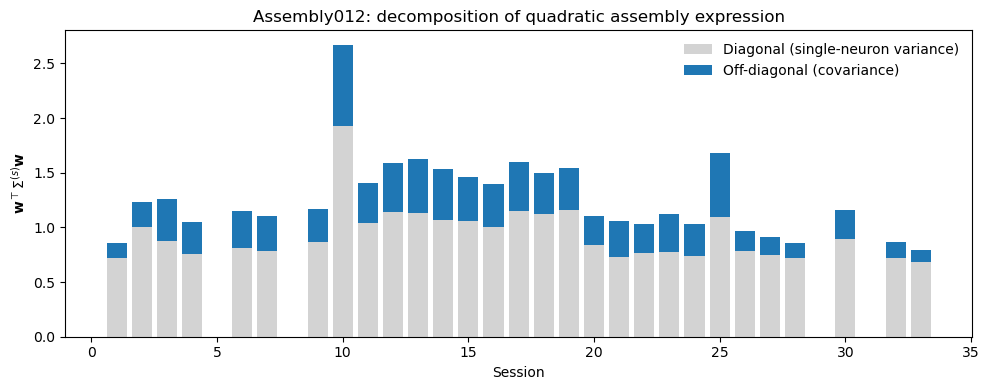

In [17]:
# plotting mean activity
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(metrics.index, metrics["diag_var"], label="Diagonal (single-neuron variance)", color="lightgray")
ax.bar(
    metrics.index,
    metrics["offdiag_var"],
    bottom=metrics["diag_var"],
    label="Off-diagonal (covariance)",
    color="tab:blue"
)

ax.set_ylabel(r"$\mathbf{w}^\top \Sigma^{(s)} \mathbf{w}$")
ax.set_xlabel("Session")
ax.set_title(f"{assembly_name}: decomposition of quadratic assembly expression")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

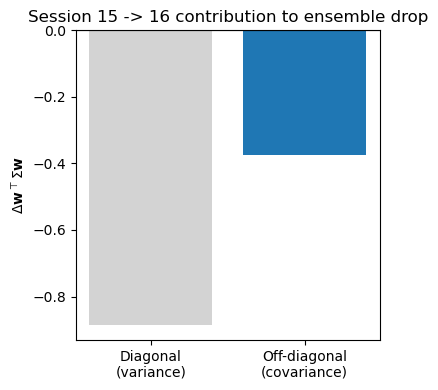

In [18]:
fig, ax = plt.subplots(figsize=(4, 4))

vals = [dVar_diag, dVar_off]
labels = ["Diagonal\n(variance)", "Off-diagonal\n(covariance)"]
colors = ["lightgray", "tab:blue"]

ax.bar(labels, vals, color=colors)
ax.axhline(0, color="black", linewidth=0.8)

ax.set_ylabel(r"$\Delta \mathbf{w}^\top \Sigma \mathbf{w}$")
ax.set_title("Session 15 -> 16 contribution to ensemble drop")

plt.tight_layout()
plt.show()


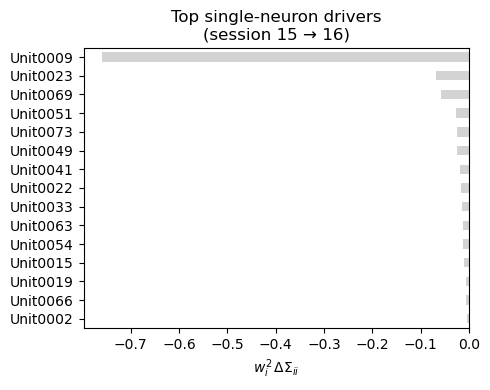

In [19]:
top_units = unit_driver.head(15)

fig, ax = plt.subplots(figsize=(5, 4))
top_units[::-1].plot(kind="barh", ax=ax, color="lightgray")

ax.set_xlabel(r"$w_i^2 \, \Delta \Sigma_{ii}$")
ax.set_title("Top single-neuron drivers\n(session 15 → 16)")

plt.tight_layout()
plt.show()


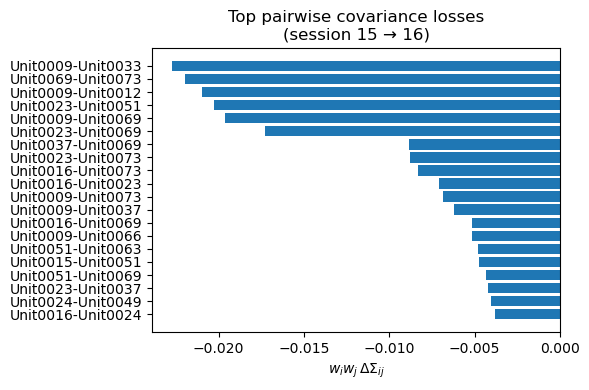

In [20]:
top_pairs = pair_driver.head(20)

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(
    range(len(top_pairs)),
    top_pairs["pair_score"],
    color="tab:blue"
)
ax.set_yticks(range(len(top_pairs)))
ax.set_yticklabels(
    [f"{u}-{v}" for u, v in zip(top_pairs["unit_i"], top_pairs["unit_j"])]
)

ax.set_xlabel(r"$w_i w_j \, \Delta \Sigma_{ij}$")
ax.set_title("Top pairwise covariance losses\n(session 15 → 16)")

ax.invert_yaxis()

plt.tight_layout()
plt.show()


Δmu_y (15→16) = 0.800656
Σ_i w_i Δmu_i = 0.800656


,mu15,mu16,dmu,w,w*dmu
Unit0051,-0.071489,-0.019799,0.051691,-0.324746,-0.016786
Unit0033,-0.175705,-0.020901,0.154804,-0.089501,-0.013855
Unit0041,0.105872,-0.061609,-0.167481,0.069932,-0.011712
Unit0012,0.166363,0.189798,0.023435,-0.309570,-0.007255
Unit0003,-0.037849,0.008062,0.045911,-0.132285,-0.006073
Unit0029,-0.415155,-0.569433,-0.154278,0.037640,-0.005807
Unit0009,0.008248,0.039007,0.030759,-0.165999,-0.005106
Unit0021,1.645416,1.839777,0.194361,-0.023008,-0.004472
Unit0042,-0.096515,-0.193603,-0.097089,0.045689,-0.004436
Unit0046,0.555434,0.609366,0.053932,-0.081025,-0.004370


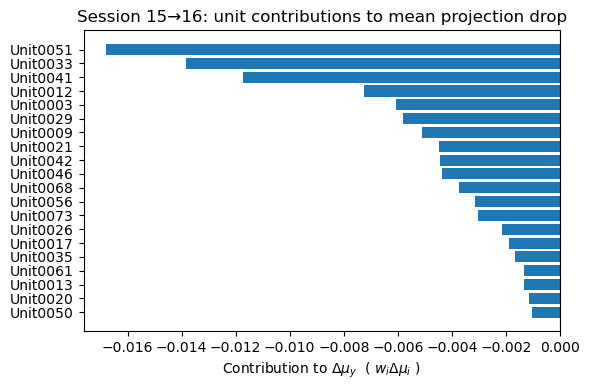

In [21]:
# --- Decompose mean projection drop: Δmu_y = Σ_i w_i Δmu_i ---

s_prev, s_drop = 15, 16  # explicitly

# Get common units and X matrices as you already do
U_prev = units_by_session[s_prev]
U_drop = units_by_session[s_drop]
common_units = sorted(set(U_prev).intersection(U_drop))

X_prev = get_X_session_common(s_prev, common_units)
X_drop = get_X_session_common(s_drop, common_units)

w_common = w_raw.loc[common_units].astype(float).values
if renorm_weights:
    nrm = np.linalg.norm(w_common)
    if nrm > 0:
        w_common = w_common / nrm

# per-unit means in each session
mu_prev_units = pd.Series(X_prev.mean(axis=0), index=common_units, name="mu15")
mu_drop_units = pd.Series(X_drop.mean(axis=0), index=common_units, name="mu16")
dmu_units = (mu_drop_units - mu_prev_units).rename("dmu")

# per-unit contributions to Δmu_y
contrib = (pd.Series(w_common, index=common_units, name="w") * dmu_units).rename("w*dmu")
contrib_sorted = contrib.sort_values()  # most negative drive the drop if Δmu_y is negative

# sanity check: sum of contributions equals Δmu_y
y_prev = X_prev @ w_common
y_drop = X_drop @ w_common
dmu_y = float(y_drop.mean() - y_prev.mean())

print(f"Δmu_y (15→16) = {dmu_y:.6g}")
print(f"Σ_i w_i Δmu_i = {contrib.sum():.6g}")

display(
    pd.concat([mu_prev_units, mu_drop_units, dmu_units, pd.Series(w_common, index=common_units, name="w"), contrib], axis=1)
      .sort_values("w*dmu")
      .head(20)
)


topk = 20
top = contrib_sorted.head(topk)[::-1]  # reverse for horizontal plot

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(top.index, top.values)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(r"Contribution to $\Delta \mu_y$  ( $w_i \Delta \mu_i$ )")
ax.set_title("Session 15→16: unit contributions to mean projection drop")
plt.tight_layout()
plt.show()

In [22]:
mu15 = float(y_prev.mean())
mu16 = float(y_drop.mean())
var15 = float(y_prev.var(ddof=1))
var16 = float(y_drop.var(ddof=1))

Ey2_15 = float((y_prev**2).mean())
Ey2_16 = float((y_drop**2).mean())

print("Mean quadratic activity decomposition (15→16):")
print(f"ΔE[y^2]     = {Ey2_16 - Ey2_15:.6g}")
print(f"ΔVar(y)     = {var16 - var15:.6g}")
print(f"Δ(mu_y^2)   = {mu16**2 - mu15**2:.6g}")
print(f"Sum check   = {(var16 - var15) + (mu16**2 - mu15**2):.6g}")


Mean quadratic activity decomposition (15→16):
ΔE[y^2]     = -1.6743
ΔVar(y)     = -0.0595782
Δ(mu_y^2)   = -1.61473
Sum check   = -1.6743


In [23]:
# calculate std for all UNIt columns in fr and calculate average
avg_std = []
for col in fr.columns:
    if isinstance(col, str) and col.startswith('Unit'):
        # print(f"{col}: {fr[col].std()}")
        avg_std.append(fr[col].std())
average_std = np.mean(avg_std)

# means of neuron frs
means = []
for col in fr.columns: 
    if isinstance(col, str) and col.startswith('Unit'):
        print(f"{col}: {fr[col].mean()}")
        means.append(fr[col].mean())

print(min(means))
print(f'average std {avg_std}')

Unit0001: 0.8270905975622198
Unit0002: 3.332068032191662
Unit0003: 0.20412358141237616
Unit0004: 0.3443694599314637
Unit0005: 0.42928967094168413
Unit0006: 0.5830950266163347
Unit0007: 5.628702131107204
Unit0008: 2.5995749488378235
Unit0009: 0.13994580710209029
Unit0010: 0.36394911989053397
Unit0011: 0.05365652025181993
Unit0012: 3.0644418371572435
Unit0013: 0.06337133237710575
Unit0014: 0.0312636907584005
Unit0015: 28.28966419007724
Unit0016: 5.352636427469738
Unit0017: 2.930722511957846
Unit0018: 0.029669561355602635
Unit0019: 1.9706815222022842
Unit0020: 2.761125897963715
Unit0021: 3.4790842720567494
Unit0022: 8.154234457800957
Unit0023: 4.59428093886345
Unit0024: 23.06585217281713
Unit0025: 9.31039087302778
Unit0026: 2.382398260786067
Unit0027: 5.49179454710221
Unit0028: 1.0199802553007615
Unit0029: 13.719115149405559
Unit0030: 0.8923373762955583
Unit0031: 2.964761863323471
Unit0032: 2.548769107047477
Unit0033: 9.405344722043846
Unit0034: 5.403836112994893
Unit0035: 5.9645008011906

In [24]:
sessions = [16, ]
assembly_name = "Assembly012"
target = "rms_a"                 # "var_a" 
min_T = 200
min_finite_frac_per_unit = 0.99  # keep units that are finite in >=99% of rows for that session
min_units = 10
renorm_weights = True


Z_df = fr_z_all_sess.copy()#.loc[fr.index.get_level_values("session_id").isin(sessions)]
unit_cols = [c for c in Z_df.columns if isinstance(c, str) and c.startswith("Unit")]

w_raw = ensambles[assembly_name].copy()
if not all(isinstance(i, str) and i.startswith("Unit") for i in w_raw.index):
    try:
        w_raw.index = [f"Unit{int(i)+1:04d}" for i in w_raw.index]
    except Exception as e:
        raise ValueError("Could not map weight index to UnitXXXX.") from e

# Use only units present in data
units_all = [u for u in w_raw.index if u in unit_cols]
if len(units_all) < 2:
    raise ValueError("Too few overlapping units between weights and fr_z_scored.")

Z_units = Z_df[units_all]

def iter_sessions(Z: pd.DataFrame):
    if isinstance(Z.index, pd.MultiIndex) and "session_id" in Z.index.names:
        for s in sorted(Z.index.get_level_values("session_id").unique()):
            yield s, Z.xs(s, level="session_id")
        return
    if Z.index.name == "session_id":
        for s in sorted(Z.index.unique()):
            yield s, Z.loc[s]
        return
    if "session_id" in Z.columns:
        for s, g in Z.groupby("session_id", sort=True):
            yield s, g.drop(columns=["session_id"])
        return
    raise ValueError("Cannot find session_id in fr_z_scored (neither index level nor column).")


# Per-session computation with column-wise filtering

rows = []
Sigma_by_session = {}
units_by_session = {}
w_by_session = {}

for s, Z_s in iter_sessions(Z_units):
    X = np.asarray(Z_s.values, dtype=float)  # shape (T, N_all)
    T_raw, N_all = X.shape

    if T_raw == 0:
        rows.append({"session_id": s, "T_raw": 0, "T_used": 0, "N_used": 0,
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    # keep units that are finite in most rows (per-session)
    finite_mask = np.isfinite(X)  # (T, N_all)
    finite_frac = finite_mask.mean(axis=0)  # (N_all,)
    keep_cols = finite_frac >= min_finite_frac_per_unit

    if keep_cols.sum() < min_units:
        rows.append({"session_id": s, "T_raw": T_raw, "T_used": 0, "N_used": int(keep_cols.sum()),
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    kept_units = list(np.array(units_all)[keep_cols])

    # subset X and drop rows that still have any NaN/inf (rare after column filter)
    Xk = X[:, keep_cols]
    ok_rows = np.isfinite(Xk).all(axis=1)
    Xk = Xk[ok_rows, :]
    T_used, N_used = Xk.shape

    if T_used < min_T or N_used < min_units:
        rows.append({"session_id": s, "T_raw": T_raw, "T_used": T_used, "N_used": N_used,
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    # align weights to kept units
    w_s = w_raw.loc[kept_units].astype(float).values

    # Optional: renormalize weights so that comparisons across sessions are not dominated by changing N_used
    if renorm_weights:
        norm = np.linalg.norm(w_s)
        if norm > 0:
            w_s = w_s / norm

    # assembly activation and covariance decomposition
    a = Xk @ w_s
    mean_a = float(np.mean(a))

    Sigma = np.cov(Xk, rowvar=False, bias=False)
    var_a = float(w_s.T @ Sigma @ w_s)
    diag_var = float(np.sum((w_s ** 2) * np.diag(Sigma)))
    offdiag_var = float(var_a - diag_var)

    rows.append({"session_id": s, "T_raw": T_raw, "T_used": T_used, "N_used": N_used,
                 "mean_a": mean_a, "var_a": var_a, "diag_var": diag_var, "offdiag_var": offdiag_var})

    Sigma_by_session[s] = Sigma
    units_by_session[s] = kept_units
    w_by_session[s] = w_s

metrics = pd.DataFrame(rows).set_index("session_id").sort_index()
metrics["rms_a"] = np.sqrt(metrics["var_a"])
metrics["diag_frac"] = metrics["diag_var"] / metrics["var_a"]
metrics["offdiag_frac"] = metrics["offdiag_var"] / metrics["var_a"]

display(metrics)

# Find largest drop safely
valid = metrics[target].dropna()
if valid.shape[0] < 2:
    raise ValueError(
        f"Not enough valid sessions for target={target}. "
        f"Valid sessions={valid.shape[0]}. "
        f"Try lowering min_T, lowering min_finite_frac_per_unit, or check why many units are NaN."
    )

delta = valid.diff().dropna()
drop_session = delta.idxmin()
prev_session = valid.index[valid.index.get_loc(drop_session) - 1]

print(f"\nLargest drop in {target}: session {prev_session} -> {drop_session} (Δ={delta.loc[drop_session]:.6g})")
print(f"Session sizes: prev(T={metrics.loc[prev_session,'T_used']}, N={metrics.loc[prev_session,'N_used']}), "
      f"drop(T={metrics.loc[drop_session,'T_used']}, N={metrics.loc[drop_session,'N_used']})")


# Attribution for that drop (only on common kept units)
U_prev = units_by_session[prev_session]
U_drop = units_by_session[drop_session]
common_units = sorted(set(U_prev).intersection(U_drop))

if len(common_units) < min_units:
    raise ValueError(
        f"Too few common units between prev and drop sessions for attribution: {len(common_units)}. "
        f"This indicates strong session-to-session changes in which units are finite."
    )

# Recompute Sigma on common units only (consistent dimensionality)
def get_X_session_common(s, common_units):
    Z_s = next(g for sid, g in iter_sessions(Z_units) if sid == s)  # session df with all units_all
    X = Z_s[common_units].to_numpy(dtype=float)
    ok = np.isfinite(X).all(axis=1)
    return X[ok, :]

X_prev = get_X_session_common(prev_session, common_units)
X_drop = get_X_session_common(drop_session, common_units)

if X_prev.shape[0] < min_T or X_drop.shape[0] < min_T:
    raise ValueError("After restricting to common units, not enough finite rows remain for covariance.")

Sigma_prev = np.cov(X_prev, rowvar=False, bias=False)
Sigma_drop = np.cov(X_drop, rowvar=False, bias=False)
dSigma = Sigma_drop - Sigma_prev

# weights restricted to common units (and optionally renormalized)
w_common = w_raw.loc[common_units].astype(float).values
if renorm_weights:
    norm = np.linalg.norm(w_common)
    if norm > 0:
        w_common = w_common / norm

dVar_total = float(w_common.T @ dSigma @ w_common)
dVar_diag  = float(np.sum((w_common ** 2) * np.diag(dSigma)))
dVar_off   = float(dVar_total - dVar_diag)

print(f"\nAttribution on common units (N={len(common_units)}):")
print(f" delta Var(a) total:   {dVar_total:.6g}")
print(f"  diagonal part: {dVar_diag:.6g}")
print(f"  offdiag part:  {dVar_off:.6g}")

# unit and pair driver scores
unit_driver = pd.Series((w_common ** 2) * np.diag(dSigma), index=common_units).sort_values()

C = np.outer(w_common, w_common) * dSigma
np.fill_diagonal(C, 0.0)

pair_rows = []
N = len(common_units)
for i in range(N):
    for j in range(i + 1, N):
        pair_rows.append((common_units[i], common_units[j], C[i, j]))

pair_driver = pd.DataFrame(pair_rows, columns=["unit_i", "unit_j", "pair_score"]).sort_values("pair_score")

print("\nTop unit-level diagonal drivers (most negative):")
display(unit_driver.head(15).to_frame("d_i = w_i^2 * Sigma_ii"))

print("\nTop pair-level off diagonal drivers (most negative):")
display(pair_driver.head(20))


,T_raw,T_used,N_used,mean_a,var_a,diag_var,offdiag_var,rms_a,diag_frac,offdiag_frac
session_id,,,,,,,,,,
1,32200,32200,77,-0.587848,0.855076,0.721074,0.134002,0.924703,0.843287,0.156713
2,53592,53592,77,-0.931100,1.235253,1.002494,0.232759,1.111419,0.811570,0.188430
3,33834,33834,77,-0.580334,1.258148,0.873254,0.384894,1.121672,0.694079,0.305921
4,38805,38805,77,-0.648255,1.048759,0.758276,0.290483,1.024089,0.723022,0.276978
6,27459,27459,77,-0.420814,1.154376,0.808455,0.345921,1.074419,0.700339,0.299661
7,38213,38213,77,-0.779637,1.105578,0.783918,0.321660,1.051464,0.709057,0.290943
9,46119,46119,77,-1.037247,1.171773,0.870666,0.301107,1.082485,0.743033,0.256967
10,3000,3000,77,-1.520986,2.669704,1.927595,0.742109,1.633923,0.722026,0.277974
11,42833,42833,77,-1.078801,1.408527,1.041020,0.367507,1.186814,0.739084,0.260916



Largest drop in rms_a: session 10 -> 11 (Δ=-0.447109)
Session sizes: prev(T=3000, N=77), drop(T=42833, N=77)

Attribution on common units (N=77):
 delta Var(a) total:   -1.26118
  diagonal part: -0.886575
  offdiag part:  -0.374603

Top unit-level diagonal drivers (most negative):


,d_i = w_i^2 * Sigma_ii
Unit0009,-0.759138
Unit0023,-0.068107
Unit0069,-0.058557
Unit0051,-0.026845
Unit0073,-0.024946
Unit0049,-0.023680
Unit0041,-0.018822
Unit0022,-0.015747
Unit0033,-0.014953
Unit0063,-0.012488



Top pair-level off diagonal drivers (most negative):


,unit_i,unit_j,pair_score
603,Unit0009,Unit0033,-0.022743
2893,Unit0069,Unit0073,-0.021957
582,Unit0009,Unit0012,-0.020998
1468,Unit0023,Unit0051,-0.020275
639,Unit0009,Unit0069,-0.019626
1486,Unit0023,Unit0069,-0.017257
2137,Unit0037,Unit0069,-0.008832
1490,Unit0023,Unit0073,-0.008793
1091,Unit0016,Unit0073,-0.008347
1041,Unit0016,Unit0023,-0.007104


In [25]:
s = 15
neuron_data_s15 = fr_track.xs(s, level=2)[fr_track.xs(s, level=2)['trial_id'] == 23]
unit_cols = [col for col in neuron_data_s15.columns if isinstance(col, str) and col.startswith('Unit')]
neuron_data_s15 = neuron_data_s15[unit_cols]

corr_matrix = neuron_data_s15.corr()

reversed_order = neurons_ordered[::-1]
unit_order = [f'Unit{i+1:04d}' for i in reversed_order if f'Unit{i+1:04d}' in corr_matrix.columns]

corr_matrix_ordered = corr_matrix.loc[unit_order, unit_order]

fig = px.imshow(
    corr_matrix_ordered,
    aspect='auto',
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    labels=dict(x="Neurons", y="Neurons", color="Pearson r"),
    title=f"Neuron-Neuron Pearson Correlation Matrix (Session {s}, Assembly012 ordering reversed)"
)

fig.update_xaxes(tickangle=90, tickfont=dict(size=6))
fig.update_yaxes(tickfont=dict(size=6))
fig.update_layout(width=900, height=900)

fig.show()

In [26]:
# selectiung only the data of ens_data in the cue zone and right before the reward zones (-95 to 10; 148-151; 168-171)
ens_data_selected = ens_data[(ens_data['from_position_bin'] >= (-95)) & (ens_data['from_position_bin'] <= 10)]
# adding reward zones with bins 148-151; 168-171
ens_data_selected = pd.concat([
    ens_data_selected,
    ens_data[(ens_data['from_position_bin'] >= 148) & (ens_data['from_position_bin'] <= 151)],
    ens_data[(ens_data['from_position_bin'] >= 168) & (ens_data['from_position_bin'] <= 171)]
])

In [27]:
df = ens_data

# If session_id is in the index, bring it back as a column
if "session_id" not in df.columns:
    if isinstance(df.index, pd.MultiIndex) and "session_id" in df.index.names:
        df = df.reset_index()
    elif df.index.name == "session_id":
        df = df.reset_index()

trial_avg = (
    df.groupby(["session_id", "from_position_bin", "cue"], as_index=False)["Assembly012"]
      .mean()
      .rename(columns={"Assembly012": "Assembly012_mean"})
)

trial_avg = trial_avg[trial_avg["cue"].isin([1, 2])].copy()

# sorting x-axis values
pos_numeric = pd.to_numeric(trial_avg["from_position_bin"], errors="coerce")
if pos_numeric.notna().any():
    trial_avg["_pos"] = pos_numeric
    x_order = np.sort(trial_avg["_pos"].dropna().unique())
    # keep a numeric x for correct ordering/spacing
    trial_avg["_x"] = trial_avg["_pos"]
    x_ticks = x_order
    x_ticktext = [str(int(x)) if float(x).is_integer() else str(x) for x in x_order]
else:
    # fallback: treat as ordered categorical by appearance
    trial_avg["_x"] = trial_avg["from_position_bin"].astype(str)
    x_order = list(pd.unique(trial_avg["_x"]))
    x_ticks = x_order
    x_ticktext = x_order

# Ridgeline plot parameters
sessions = sorted(trial_avg["session_id"].unique())
dy = 0.8          # vertical spacing between sessions
cue_offset = 0.02 # vertical separation between cue 1 and cue 2 within a session
amp = 0.2

fig = go.Figure()

for i, s in enumerate(sessions):
    base = i * dy

    for cue, off in [(1, -cue_offset), (2, +cue_offset)]:
        sub = trial_avg[(trial_avg["session_id"] == s) & (trial_avg["cue"] == cue)].copy()

        # Ensure every x bin exists, fill missing with 0 (or np.nan if you prefer gaps)
        if pos_numeric.notna().any():
            sub = sub.set_index("_x").reindex(x_order).reset_index()
        else:
            sub = sub.set_index("_x").reindex(x_order).reset_index()

        y = sub["Assembly012_mean"].fillna(0.0).to_numpy()
        y_ridge = base + off + amp * y

        fig.add_trace(
            go.Scatter(
                x=sub["_x"],
                y=y_ridge,
                mode="lines",
                line=dict(width=1, color= cue == 1 and "orange" or "purple"),
                fill= None,
                name=f"session {s} | cue {cue}",
                hovertemplate=(
                    "session=%{customdata[0]}<br>"
                    "cue=%{customdata[1]}<br>"
                    "from_position_bin=%{x}<br>"
                    "mean(Assembly012)=%{customdata[2]:.4f}<extra></extra>"
                ),
                customdata=np.c_[np.full(len(sub), s), np.full(len(sub), cue), y],
                showlegend=True,
            )
        )



#Layout polish
fig.update_layout(
    title="Ridgeline: mean(Assembly012) per from_position_bin, one ridge per session",
    xaxis_title="from_position_bin",
    yaxis_title="session_id (stacked ridges)",
    # hovermode="x",
    height=max(450, 40 * len(sessions) + 200),
)

# Put session labels on the y-axis at each session baseline
fig.update_yaxes(
    tickmode="array",
    tickvals=[i * dy for i in range(len(sessions))],
    ticktext=[str(s) for s in sessions],
)

fig.add_vrect(x0=-80, x1=25,  fillcolor="orange", opacity=0.2, layer="below", line_width=0)
fig.add_vrect(x0=50,  x1=110, fillcolor="grey",   opacity=0.2, layer="below", line_width=0)
fig.add_vrect(x0=170, x1=230, fillcolor="grey",   opacity=0.2, layer="below", line_width=0)


if pos_numeric.notna().any():
    fig.update_xaxes(
        tickmode="array",
        ticktext=x_ticktext,
        showgrid=False, zeroline=False
    )

fig.show()


In [28]:
df = ens_data
need_reset = False
if isinstance(df.index, pd.MultiIndex):
    need_reset = any(name in df.index.names for name in ["session_id", "trial_id"])
elif df.index.name in ["session_id", "trial_id"]:
    need_reset = True

if need_reset:
    df = df.reset_index()

# session selector
# session_to_plot = df["session_id"].dropna().unique()[0]  # first available session as default
session_to_plot = 15

df_s = df.loc[df["session_id"] == session_to_plot].copy()
#df_s = df_s[df_s["cue"].isin([1, 2])].copy()

# If "cue" is constant per trial, this will keep it; if not, it will take the first observed cue per trial
trial_cue = (
    df_s.groupby("trial_id", as_index=True)["cue"]
        .agg(lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan)
)

# Aggregate within trial and position bin
trial_avg = (
    df_s.groupby(["trial_id", "from_position_bin"], as_index=False)["Assembly012"]
        .mean()
        .rename(columns={"Assembly012": "Assembly012_mean"})
)


# Build ordered numeric x if possible
pos_numeric = pd.to_numeric(trial_avg["from_position_bin"], errors="coerce")
if pos_numeric.notna().any():
    trial_avg["_x"] = pos_numeric
    x_order = np.sort(trial_avg["_x"].dropna().unique())
    x_tickvals = x_order
    x_ticktext = [str(int(x)) if float(x).is_integer() else str(x) for x in x_order]
else:
    trial_avg["_x"] = trial_avg["from_position_bin"].astype(str)
    x_order = list(pd.unique(trial_avg["_x"]))
    x_tickvals = x_order
    x_ticktext = x_order


# Ridgeline parameters
trials = sorted(trial_avg["trial_id"].unique())
dy = 0.8      #between trials
amp = 0.05    # amplitude scaling

fig = go.Figure()

for i, t in enumerate(trials):
    base = i * dy

    sub = trial_avg.loc[trial_avg["trial_id"] == t, ["_x", "Assembly012_mean"]].copy()
    sub = sub.set_index("_x").reindex(x_order).reset_index()

    y = sub["Assembly012_mean"].fillna(0.0).to_numpy()
    y_ridge = base + amp * y

    cue_t = trial_cue.get(t, np.nan)
    line_color = "orange" if cue_t == 1 else "purple"

    fig.add_trace(
        go.Scatter(
            x=sub["_x"],
            y=y_ridge,
            mode="lines",
            line=dict(width=1, color=line_color),
            name=f"trial {t}",
            hovertemplate=(
                "session=%{customdata[0]}<br>"
                "trial_id=%{customdata[1]}<br>"
                "cue=%{customdata[2]}<br>"
                "from_position_bin=%{x}<br>"
                "mean(Assembly012)=%{customdata[3]:.4f}<extra></extra>"
            ),
            customdata=np.c_[
                np.full(len(sub), session_to_plot),
                np.full(len(sub), t),
                np.full(len(sub), cue_t),
                y,
            ],
            showlegend=False,
        )
    )

# Y-axis
fig.update_yaxes(
    tickmode="array",
    tickvals=[i * dy for i in range(len(trials))],
    ticktext=[str(t) for t in trials],
    title_text="trial_id",
)

fig.update_layout(
    title=f"Ridgeline: mean(Assembly012) per from_position_bin, one ridge per trial (session {session_to_plot})",
    xaxis_title="from_position_bin",
    height=max(500, 30 * len(trials) + 250),
)

fig.update_xaxes(
    tickmode="array",
    showgrid=False,
    zeroline=False,
)

fig.add_vrect(x0=-80, x1=25,  fillcolor="orange", opacity=0.2, layer="below", line_width=0)
fig.add_vrect(x0=50,  x1=110, fillcolor="grey",   opacity=0.2, layer="below", line_width=0)
fig.add_vrect(x0=170, x1=230, fillcolor="grey",   opacity=0.2, layer="below", line_width=0)

fig.show()


In [29]:
ens_data_selected.iloc[21]

from_position_bin   -74.000000
Assembly001          -0.099148
Assembly002           0.467107
Assembly003          -0.147941
Assembly004           1.521419
Assembly005          -0.148643
Assembly006           0.234393
Assembly007          -0.004374
Assembly008          -0.276427
Assembly009           5.736478
Assembly010          -0.543661
Assembly011          -0.240814
Assembly012          -0.268701
Assembly013          -0.310847
Assembly014           0.389596
Assembly015          -0.281009
Assembly016           1.823038
Assembly017          -0.669150
Assembly018           0.275752
Assembly019          -0.948504
Assembly020           0.166078
Assembly021          -0.454322
Assembly022           0.723875
Assembly023           2.473572
cue                   1.000000
trial_outcome         0.000000
choice_R1             0.000000
choice_R2             0.000000
bin_length            0.080000
Name: (1, 1), dtype: float64

In [30]:
Assembly = 'Assembly012'
i = 14
s1 = ens_data.xs(i, level='session_id')
s1_avg = (s1.groupby(['from_position_bin','cue'], as_index=False)[Assembly].mean())
title = f'Average Ensemble Activityby Position Across Trials in Session {i}'
fig = px.line(
    s1_avg,
    x='from_position_bin',
    y=Assembly,
    color='cue',
    color_discrete_map={1: 'orange', 2: 'purple'},
    markers=True,
    title=title,
    range_y=[-1, 1.5]
)
fig.add_vrect(x0=-80, x1=25,  fillcolor="orange", opacity=0.3, layer="below", line_width=0)
fig.add_vrect(x0=50,  x1=110, fillcolor="grey",   opacity=0.4, layer="below", line_width=0)
fig.add_vrect(x0=170, x1=230, fillcolor="grey",   opacity=0.2, layer="below", line_width=0)

fig.show()


# plotting the avg. activity for each trial in session 14 in a scatter plot
s1 = ens_data_selected.xs(i, level='session_id')
s1_avg = s1.groupby('trial_id').mean().reset_index()
s1_avg['trial_id'] = s1_avg['trial_id'] - 1
title = f'Average Ensemble Activity in the Cue Zones and Before Reward Zones by Trial for Session {i}'
# fig = px.line(s1_avg, x='trial_id', y='Assembly012', title=title, range_y=[-1,2])
fig = px.line(
    s1_avg,
    x='trial_id',
    y=Assembly,
    color='cue',
    color_discrete_map={1: 'orange', 2: 'purple'},
    markers=True,
    title=title,
    range_y=[-1, 2]
)
fig.show()

In [31]:
s = 15
#i = 19
i += 1
s1_trial1 = ens_data.xs((s, i), level=('session_id', 'trial_id'))
title = f'Firing Rate by Position for Trial {i} in Session {s}'

fig = px.line(s1_trial1, x='from_position_bin', y='Assembly012', color = 'cue', title=title)
fig.add_vrect(x0=-80, x1=25, fillcolor="orange", opacity=0.3, layer="below", line_width=0)
fig.add_vrect(x0=50, x1=110, fillcolor="grey", opacity=0.4, layer="below", line_width=0)
fig.add_vrect(x0=170, x1=230, fillcolor="grey", opacity=0.2, layer="below", line_width=0)
fig.show()

print(f'Trial {i-1} is a Cue {s1_trial1["cue"]} trial in Session {s}')

Trial 14 is a Cue session_id  trial_id
15          15          1.0
            15          1.0
            15          1.0
            15          1.0
            15          1.0
                       ... 
            15          1.0
            15          1.0
            15          1.0
            15          1.0
            15          1.0
Name: cue, Length: 432, dtype: float64 trial in Session 15
